## Theta Length GLM

In [42]:
%reload_ext autoreload
%autoreload 2

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pickle

from spyglass.shijiegu.Analysis_SGU import ChangeofMind, ChangeofMindRemoteTheta, MUATheta, ChangeofMindTheta
from spyglass.shijiegu.changeOfMind_figures.figure3_thetaGLM import (return_deviation, plot_params_one_axe,
            make_mixedGLM_xy, do_GLM)
from spyglass.shijiegu.changeOfMind_triggered import (seq2, rev2, rev3, seq1, rev1)
from spyglass.shijiegu.changeOfMind import color_by_rat

In [44]:
list_of_days_animals = {}
seq_animals = {}
success_animal = {}

animal = "molly"
list_of_days_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']
seq_animals[animal] = seq2

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109','20240110']
seq_animals[animal] = rev2

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
seq_animals[animal] = seq2

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
seq_animals[animal] = seq2

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',#
                 '20231106','20231107','20231108']
seq_animals[animal] = rev2

In [45]:
output_folder = f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure3'

decode_name_long = "params_both_max_segment_run_time_2_state"
decode_name_remote = "params_both_max_run_time_2_state"
minimum_duration_long = 0.03
minimum_duration_remote = 0.02
min_posterior = 0.2
sd = 6
proportion = 0.1
hpd = False

In [46]:
# draft start

In [5]:
from spyglass.shijiegu.changeOfMind_remote_interval import load_remote_animal

[20:26:25][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


In [9]:
from spyglass.shijiegu.changeOfMind_triggered_position import load_triggered_position_decode_session_spyglass

In [7]:
animal = "molly"
day = "20220418"

In [21]:
loaded_data = load_triggered_position_decode_session_spyglass("klein20231105_.nwb", 2,
                                                               "params_both_max_segment_run_time_2_state", 0.1)

[2026-03-18 20:37:26,141][WARNING]: Skipped checksum for file with hash: 0b71f43c-cad3-ed0a-9414-b494d29c8867, and path: /stelmo/nwb/analysis/klein20231105/klein20231105_AVJKC65VMP.nwb


In [22]:
loaded_data.keys()

dict_keys(['triggered_positions_baseoff', 'triggered_decodes_baseoff', 'triggered_positions', 'triggered_trial_info'])

In [23]:
loaded_data['triggered_trial_info']

[array([50,  4]), array([68,  2]), array([78,  2]), array([78,  3])]

In [26]:
np.max(loaded_data["triggered_positions_baseoff"][2].linear_position)

29.2980005079462

In [27]:
time = loaded_data["triggered_positions_baseoff"][2].index
time[-1] - time[0]

1.977998971939087

In [33]:
nwb_copy_file_name = "klein20231105_.nwb"
q_long = {"proportion": 0.1,
                 "minimum_duration":minimum_duration_long,
                  "parameter":decode_name_long,
                  "local_parameter":f"dur_{minimum_duration_long}_sd_{sd}_hpd{hpd}",
          "epoch":2
                 }

q_long["nwb_file_name"] = nwb_copy_file_name
q_remote = q_long.copy()

In [34]:
ChangeofMindTheta() & q_long  

nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),proportion minimal amount of proportion the animal is in before it backed out,parameter parameter name,"local_parameter time in seconds, the min duration of an event","pandas pandas dataframe saved as dictionary, choice"
klein20231105_.nwb,2,0.1,params_both_max_segment_run_time_2_state,dur_0.03_sd_6_hpdFalse,=BLOB=


In [43]:
ChangeofMindRemoteTheta()

nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),proportion minimal amount of proportion the animal is in before it backed out,parameter parameter name,"remote_parameter time in seconds, the min duration of an event","pandas pandas dataframe saved as dictionary, choice"
eliot20221018_.nwb,2,0.1,params_both_max_all_maze_2_state,dur_0.02_sum_0.2,=BLOB=
eliot20221018_.nwb,2,0.1,params_both_max_run_time_2_state,dur_0.02_sum_0.2,=BLOB=
eliot20221018_.nwb,2,0.1,params_both_max_run_time_2_state,dur_0.02_sum_0.4,=BLOB=
eliot20221018_.nwb,5,0.1,params_both_max_all_maze_2_state,dur_0.02_sum_0.2,=BLOB=
eliot20221018_.nwb,5,0.1,params_both_max_run_time_2_state,dur_0.02_sum_0.2,=BLOB=
eliot20221018_.nwb,5,0.1,params_both_max_run_time_2_state,dur_0.02_sum_0.4,=BLOB=
eliot20221018_.nwb,7,0.1,params_both_max_all_maze_2_state,dur_0.02_sum_0.2,=BLOB=
eliot20221018_.nwb,7,0.1,params_both_max_run_time_2_state,dur_0.02_sum_0.2,=BLOB=
eliot20221018_.nwb,7,0.1,params_both_max_run_time_2_state,dur_0.02_sum_0.4,=BLOB=
eliot20221018_.nwb,9,0.1,params_both_max_all_maze_2_state,dur_0.02_sum_0.2,=BLOB=


In [47]:
long_df = ChangeofMindRemoteTheta().fetch1_dataframe({"nwb_file_name": nwb_copy_file_name,
                             "parameter": "params_both_max_run_time_2_state",
                             "remote_parameter": "dur_0.02_sum_0.2","epoch":4
                            })

In [48]:
long_df

,timestamp_H,Home,timestamp_O,OuterWellIndex,rewardNum,change_of_mind,has_remote_interval,remote_interval,remote_content,change_of_mind_num,...,proportion_arm3,proportion_arm4,CoMNum_by_time,CoMNum_by_arm,CoM_arm,current,future_H,future_O,past,past_reward
1,1.699216e+09,1.0,1.699216e+09,1.0,2.0,False,False,[],[],[],...,NaN,NaN,0,0,[],1.0,1.0,2.0,NaN,NaN
2,1.699216e+09,1.0,1.699216e+09,2.0,2.0,False,False,[],[],[],...,NaN,NaN,0,0,[],2.0,2.0,3.0,1.0,1.0
3,1.699216e+09,1.0,1.699216e+09,3.0,1.0,False,False,[],[],[],...,NaN,NaN,0,0,[],3.0,3.0,1.0,2.0,2.0
4,1.699216e+09,1.0,1.699216e+09,1.0,1.0,False,False,[],[],[],...,NaN,NaN,0,0,[],1.0,1.0,4.0,3.0,2.0
5,1.699216e+09,1.0,1.699216e+09,4.0,2.0,False,False,[],[],[],...,NaN,NaN,0,0,[],4.0,4.0,2.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,1.699219e+09,1.0,1.699219e+09,4.0,2.0,False,False,[],[],[],...,NaN,NaN,0,0,[],4.0,4.0,2.0,1.0,2.0
79,1.699219e+09,1.0,1.699219e+09,2.0,1.0,False,False,[],[],[],...,NaN,NaN,0,0,[],2.0,2.0,3.0,4.0,4.0
80,1.699219e+09,1.0,1.699219e+09,3.0,2.0,False,False,[],[],[],...,NaN,NaN,0,0,[],3.0,3.0,1.0,2.0,4.0
81,1.699219e+09,1.0,1.699219e+09,1.0,2.0,False,False,[],[],[],...,NaN,NaN,0,0,[],1.0,1.0,NaN,3.0,3.0


In [42]:

long_df = ChangeofMindRemoteTheta().fetch1_dataframe(q_remote)  

DataJointError: fetch1 should only return one tuple. 0 tuples found

In [41]:
long_df

,timestamp_H,Home,timestamp_O,OuterWellIndex,rewardNum,change_of_mind,long_theta,theta_dev,short_theta_dev,long_theta_intervals,...,proportion_arm3,proportion_arm4,CoMNum_by_time,CoMNum_by_arm,CoM_arm,current,future_H,future_O,past,past_reward
1,1.699211e+09,1.0,1.699211e+09,1.0,2.0,False,False,[],[],[],...,NaN,NaN,0,0,[],1.0,1.0,3.0,NaN,NaN
2,NaN,NaN,1.699211e+09,3.0,0.0,False,False,[],[],[],...,NaN,NaN,0,0,[],3.0,3.0,2.0,1.0,1.0
3,NaN,NaN,1.699211e+09,2.0,0.0,False,False,[],[],[],...,NaN,NaN,0,0,[],2.0,2.0,4.0,3.0,1.0
4,NaN,NaN,1.699211e+09,4.0,0.0,False,False,[],[],[],...,NaN,NaN,0,0,[],4.0,4.0,2.0,2.0,1.0
5,1.699211e+09,1.0,1.699211e+09,2.0,2.0,False,False,[],[],[],...,NaN,NaN,0,0,[],2.0,2.0,3.0,4.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,1.699214e+09,1.0,1.699214e+09,2.0,1.0,True,True,[57.379743406176374],[-8.895362036915913],"[(1699213925.398999, 1699213925.428999)]",...,0.116515,0.0,2,2,"[[2, 3, -9223372036854775808]]",2.0,2.0,3.0,1.0,2.0
79,1.699214e+09,1.0,1.699214e+09,3.0,1.0,False,False,[],[],[],...,NaN,NaN,0,0,[],3.0,3.0,1.0,2.0,2.0
80,1.699214e+09,1.0,1.699214e+09,1.0,1.0,False,False,[],[],[],...,NaN,NaN,0,0,[],1.0,1.0,4.0,3.0,2.0
81,1.699214e+09,1.0,1.699214e+09,4.0,2.0,False,False,[],[],[],...,NaN,NaN,0,0,[],4.0,4.0,NaN,1.0,2.0


In [39]:
long_df[long_df.long_theta].loc[50].long_theta_intervals

[(1699212992.463455, 1699212992.533455),
 (1699212994.6834538, 1699212994.7394538)]

In [ ]:
# draft end

In [65]:
# For long theta
# for each change of mind trial:
# 
# find its max proportion across all arms
# find number of change of mind events by arms
# find recent reward history
# tally if there is a long theta event or there is remote event
# features_animals = {}
# responses_animals = {}
success = {}
for animal in ["lewis","julio","molly","eliot","klein"]:
    features, responses = return_deviation(animal, list_of_days_animals[animal], seq_animals[animal],
                         minimum_duration_long, decode_name_long, sd, hpd,
                         minimum_duration_remote, decode_name_remote, min_posterior)

    output_folder = f'/stelmo/shijie/change_of_mind_analysis/figure3/alternative_GLM_forward_{animal}'
    data = {"features": features, "responses": responses}
    file_path = output_folder + '.pkl'
    with open(file_path, 'wb') as file:
        print("data saved to " + file_path)
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
    success[animal] = 1



lewis20240105_.nwb


[2026-03-19 20:14:49,238][WARNING]: Skipped checksum for file with hash: f6f6d01e-df12-3f2d-219a-dc1f29268652, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_R7YRR0BEA0.nwb
[2026-03-19 20:14:58,620][WARNING]: Skipped checksum for file with hash: da16aeb7-0d19-4fbf-f261-bd1f596cb8c4, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_M68F9R63Z4.nwb
[2026-03-19 20:15:07,948][WARNING]: Skipped checksum for file with hash: 75b17730-29f6-0b85-3b5b-b028870ead13, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_B7GFSGZN4P.nwb
[2026-03-19 20:15:17,185][WARNING]: Skipped checksum for file with hash: 7fb41f75-218a-900a-bdcf-b30434bc8d6e, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_VA7AKIXO0P.nwb
[2026-03-19 20:15:26,221][WARNING]: Skipped checksum for file with hash: 7297c6ef-67df-7d54-4fc3-bc9bf686b3e1, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_65MH5K7ZP9.nwb
[2026-03-19 20:15:35,233][WARNING]: Skipped checksum for file with hash: 96

lewis20240106_.nwb


[2026-03-19 20:15:44,288][WARNING]: Skipped checksum for file with hash: 19670c22-976b-1556-d6b1-b14afef51627, and path: /stelmo/nwb/analysis/lewis20240106/lewis20240106_ZCWM0SRJTN.nwb
[2026-03-19 20:15:53,705][WARNING]: Skipped checksum for file with hash: fdf4d47d-3b8b-e5ba-843b-4dd3bd1290ed, and path: /stelmo/nwb/analysis/lewis20240106/lewis20240106_V5P5UKXPCG.nwb
[2026-03-19 20:16:02,985][WARNING]: Skipped checksum for file with hash: a9837470-c8ea-7918-b796-1837d6dec6b6, and path: /stelmo/nwb/analysis/lewis20240106/lewis20240106_E6TFNKQY8M.nwb
[2026-03-19 20:16:12,040][WARNING]: Skipped checksum for file with hash: 2669b264-3f56-34d2-a063-4c1ef8f04f79, and path: /stelmo/nwb/analysis/lewis20240107/lewis20240107_YS6K52AFH8.nwb


lewis20240107_.nwb


...

klein20231107_.nwb


[2026-03-19 20:37:51,852][WARNING]: Skipped checksum for file with hash: 171ec426-ce70-11fd-d346-d836fc996ed4, and path: /stelmo/nwb/analysis/klein20231107/klein20231107_9T3OZZT26N.nwb
[2026-03-19 20:38:00,932][WARNING]: Skipped checksum for file with hash: 5de59485-356b-277c-eeea-08734ae0cc03, and path: /stelmo/nwb/analysis/klein20231107/klein20231107_G8HANRV4HC.nwb
[2026-03-19 20:38:09,941][WARNING]: Skipped checksum for file with hash: d897b095-51ce-045f-9377-89ea23d2a513, and path: /stelmo/nwb/analysis/klein20231107/klein20231107_3NQP3SGI4D.nwb
[2026-03-19 20:38:18,923][WARNING]: Skipped checksum for file with hash: a0ab5445-234f-f948-7aa9-f7cd314b828a, and path: /stelmo/nwb/analysis/klein20231107/klein20231107_MI0FGC70NG.nwb
[2026-03-19 20:38:27,936][WARNING]: Skipped checksum for file with hash: ee1f6928-ae39-11b8-2f8e-3eb224fbee44, and path: /stelmo/nwb/analysis/klein20231108/klein20231108_6AXOYZ57R4.nwb


klein20231108_.nwb


[2026-03-19 20:38:36,931][WARNING]: Skipped checksum for file with hash: 19412b8c-1774-c4b3-99bb-7a7f7e53a8c9, and path: /stelmo/nwb/analysis/klein20231108/klein20231108_HZBTC9AT5K.nwb
[2026-03-19 20:38:45,941][WARNING]: Skipped checksum for file with hash: 9e72d271-b624-ed8e-45c9-e8fb9f59f82d, and path: /stelmo/nwb/analysis/klein20231108/klein20231108_61DEUU83YO.nwb
[2026-03-19 20:38:54,914][WARNING]: Skipped checksum for file with hash: 64ec686e-877e-f86e-1524-d3fb32d8c676, and path: /stelmo/nwb/analysis/klein20231108/klein20231108_1NUE89C7PQ.nwb


data saved to /stelmo/shijie/change_of_mind_analysis/figure3/alternative_GLM_forward_klein.pkl


In [66]:
success

{'lewis': 1, 'julio': 1, 'molly': 1, 'eliot': 1, 'klein': 1}

### per animal GLM

#### Long theta event

Optimization terminated successfully.
         Current function value: 0.366846
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.245538
         Iterations 8
7.4799999999999995 0.03
Optimization terminated successfully.
         Current function value: 0.208800
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.277570
         Iterations 8
7.4799999999999995 0.03
Optimization terminated successfully.
         Current function value: 0.415022
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.609200
         Iterations 5
7.4799999999999995 0.03
Optimization terminated successfully.
         Current function value: 0.451945
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.479465
         Iterations 6
7.4799999999999995 0.03


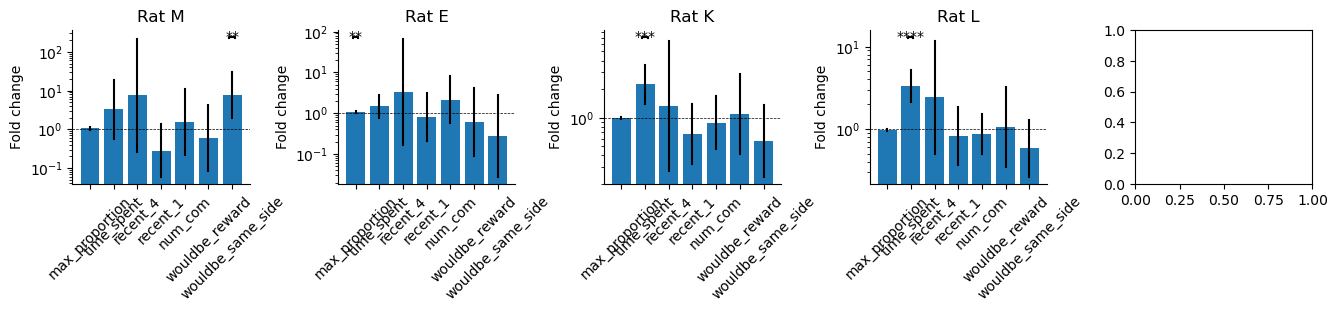

In [68]:
fig, axes = plt.subplots(1,5,figsize=(16, 2))
plt.subplots_adjust(wspace=0.5)

animal_ind = 0
for animal in ["molly","eliot","klein","lewis"]:

    output_folder = f'/stelmo/shijie/change_of_mind_analysis/figure3/alternative_GLM_forward_{animal}'
    file_path = output_folder + '.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file)
    
    feature_animal = data["features"]
    response_animal = data["responses"]
    feature_names = ['max_proportion', 'time_spent', 'recent_4', 'recent_1', 'num_com', 'wouldbe_reward', 'wouldbe_same_side']
    x_dict = {feature: feature_animal[feature] for feature in feature_names}
    y1 = response_animal["long_theta"]
    y2 = response_animal["remote_theta"]
    
    x = pd.DataFrame(x_dict)
    x_ = sm.add_constant(x)
    results_long = sm.Logit(y1, x_).fit()
    results_remote = sm.Logit(y2, x_).fit()
    
    plot_params_one_axe(axes[animal_ind], results_long, f"Rat {animal[0].upper()}")

    animal_ind += 1

### Remote theta event

Optimization terminated successfully.
         Current function value: 0.366846
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.245538
         Iterations 8
7.4799999999999995 0.03
7.4799999999999995 0.03
Optimization terminated successfully.
         Current function value: 0.208800
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.277570
         Iterations 8
7.4799999999999995 0.03
7.4799999999999995 0.03
Optimization terminated successfully.
         Current function value: 0.415022
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.609200
         Iterations 5
7.4799999999999995 0.03
Optimization terminated successfully.
         Current function value: 0.451945
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.479465
         Iterations 6
7.4799999999999995 0.03


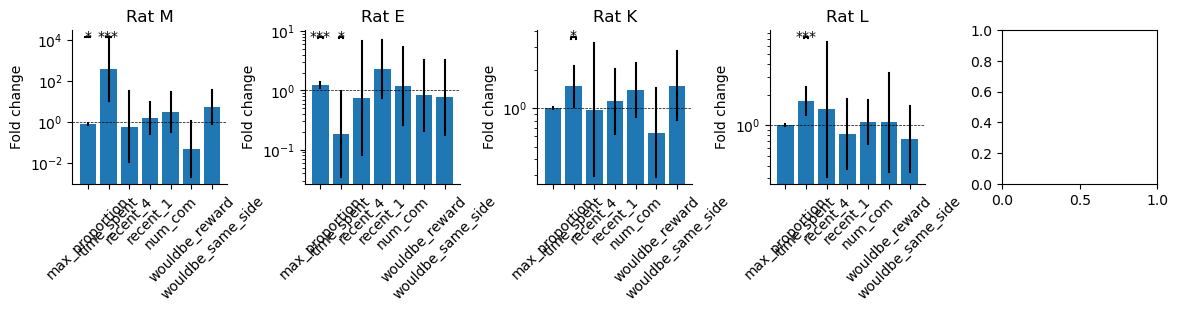

In [70]:
fig, axes = plt.subplots(1,5,figsize=(14, 2))
plt.subplots_adjust(wspace=0.5)

animal_ind = 0
for animal in ["molly","eliot","klein","lewis"]:

    output_folder = f'/stelmo/shijie/change_of_mind_analysis/figure3/alternative_GLM_forward_{animal}'
    file_path = output_folder + '.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file)
    
    feature_animal = data["features"]
    response_animal = data["responses"]
    feature_names = ['max_proportion', 'time_spent', 'recent_4', 'recent_1', 'num_com', 'wouldbe_reward', 'wouldbe_same_side']
    x_dict = {feature: feature_animal[feature] for feature in feature_names}
    y1 = response_animal["long_theta"]
    y2 = response_animal["remote_theta"]
    
    x = pd.DataFrame(x_dict)
    x_ = sm.add_constant(x)
    results_long = sm.Logit(y1, x_).fit()
    results_remote = sm.Logit(y2, x_).fit()
    
    plot_params_one_axe(axes[animal_ind], results_remote, f"Rat {animal[0].upper()}")

    animal_ind += 1

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/figure3_event_GLM_by_rat.pdf"
fig.savefig(file_path, format="pdf", dpi=300, bbox_inches="tight")

### Prettier plot

In [71]:
from spyglass.shijiegu.changeOfMind_figures.extra_correctness import model2numbers

Optimization terminated successfully.
         Current function value: 0.382115
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.294145
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.232069
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.340237
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.316717
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.404838
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.415270
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.612932
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.462320
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.481168
  

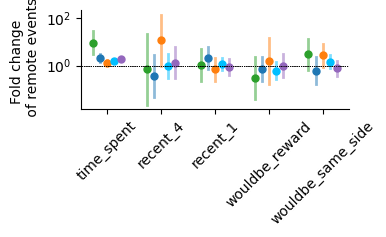

In [78]:
feature_names = ['time_spent', 'recent_4', 'recent_1', 'wouldbe_reward', 'wouldbe_same_side']

fig, ax1 = plt.subplots(1, 1, figsize=(4.5, 3),
                               sharex = True)

animal_ind = 0 
animals = ["molly", "eliot", "julio", "klein", "lewis"]
for animal in animals:
    output_folder = f'/stelmo/shijie/change_of_mind_analysis/figure3/alternative_GLM_forward_{animal}'
    file_path = output_folder + '.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file)
    
    """Logistic Regression"""
    feature_animal = data["features"]
    response_animal = data["responses"]
    
    x_dict = {feature: feature_animal[feature] for feature in feature_names}
    y1 = response_animal["long_theta"]
    y2 = response_animal["remote_theta"]
    
    x = pd.DataFrame(x_dict)
    x_ = sm.add_constant(x)
    results_long = sm.Logit(y1, x_).fit()
    results_remote = sm.Logit(y2, x_).fit()

    params2, coef_names2, coef_est2, pvalues2, CI2 = model2numbers(results_remote)
    coef_est2 = np.exp(coef_est2)
    CI2 = np.exp(CI2)

    # either
    dt = 0.38
    dx=0.05
    feature_count = 0
    feature_inds = np.arange(len(coef_names2))[np.isin(feature_names, coef_names2)]
    for axes in [ax1]:
        for ind in feature_inds:
        
            xloc = animal_ind*dx + dt*feature_count
            axes.scatter(xloc, coef_est2[ind], marker = ".", s = 100, color = color_by_rat[animal])
            axes.plot([xloc, xloc], [CI2.iloc[ind][0], CI2.iloc[ind][1]], alpha = 0.5, linewidth = 2, color = color_by_rat[animal])

            feature_count += 1
        # axhline
        axes.axhline(1,-0.1, xloc + .1, color = 'k', linestyle = "dotted", linewidth = 0.5)
        axes.spines[['right', 'top']].set_visible(False)

    ax1.set_xticks(feature_inds * dt + dx * 2)
    ax1.set_xticklabels(feature_names, rotation = 45)

    ax1.set_ylabel("Fold change \n of remote events")
    ax1.set_yscale('log') 
        
    animal_ind += 1

plt.subplots_adjust(hspace=0.3)
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/figure3_remote_fold_change_factor_by_rat.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")

Optimization terminated successfully.
         Current function value: 0.366846
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.208800
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.285788
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.415022
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.451945
         Iterations 6


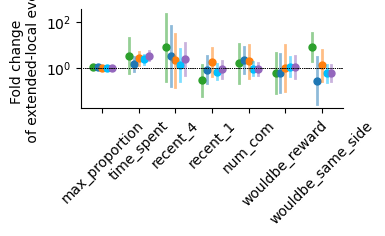

In [73]:
feature_names = ['max_proportion', 'recent_4', 'recent_1']
fig, ax1 = plt.subplots(1, 1, figsize=(4.5, 3),
                               sharex = True)

animal_ind = 0 
animals = ["molly", "eliot", "julio", "klein", "lewis"]
for animal in animals:

    output_folder = f'/stelmo/shijie/change_of_mind_analysis/figure3/alternative_GLM_forward_{animal}'
    file_path = output_folder + '.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file)
    
    """Logistic Regression"""
    feature_animal = data["features"]
    response_animal = data["responses"]
    feature_names = ['max_proportion', 'time_spent', 'recent_4', 'recent_1', 'num_com', 'wouldbe_reward', 'wouldbe_same_side']
    x_dict = {feature: feature_animal[feature] for feature in feature_names}
    y1 = response_animal["long_theta"]
    y2 = response_animal["remote_theta"]
    
    x = pd.DataFrame(x_dict)
    x_ = sm.add_constant(x)
    results_long = sm.Logit(y1, x_).fit()

    params2, coef_names2, coef_est2, pvalues2, CI2 = model2numbers(results_long)
    coef_est2 = np.exp(coef_est2)
    CI2 = np.exp(CI2)

    # either
    dt = 0.38
    dx=0.05
    feature_count = 0
    feature_inds = np.arange(len(coef_names2))[np.isin(feature_names, coef_names2)]
    for axes in [ax1]:
        for ind in feature_inds:
        
            xloc = animal_ind*dx + dt*feature_count
            axes.scatter(xloc, coef_est2[ind], marker = ".", s = 100, color = color_by_rat[animal])
            axes.plot([xloc, xloc], [CI2.iloc[ind][0], CI2.iloc[ind][1]], alpha = 0.5, linewidth = 2, color = color_by_rat[animal])

            feature_count += 1
        # axhline
        axes.axhline(1,-0.1, xloc + .1, color = 'k', linestyle = "dotted", linewidth = 0.5)
        axes.spines[['right', 'top']].set_visible(False)

    ax1.set_xticks(feature_inds * dt + dx * 2)
    ax1.set_xticklabels(feature_names, rotation = 45)

    ax1.set_ylabel("Fold change \n of extended-local events")
    ax1.set_yscale('log') 
        
    animal_ind += 1

plt.subplots_adjust(hspace=0.3)
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/figure3_local_extended_fold_change_factor_by_rat.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")

### Mixed linear effect

In [58]:
feature_animals[animal].keys()

dict_keys(['max_proportion', 'num_com', 'recent_4', 'recent_1', 'wouldbe_reward', 'wouldbe_same_side', 'time_spent'])

In [74]:
feature_names = ['max_proportion', 'time_spent', 'num_com','recent_4', 'recent_1', 'wouldbe_reward', 'wouldbe_same_side']
animals = ["molly","eliot","julio","klein","lewis"]
feature_animals = {}
response_animals = {}

for animal in animals:

    output_folder = f'/stelmo/shijie/change_of_mind_analysis/figure3/alternative_GLM_forward_{animal}'
    file_path = output_folder + '.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file)
    
    """Logistic Regression"""
    feature_animals[animal] = data["features"]
    response_animals[animal] = data["responses"]

GLM_xy = make_mixedGLM_xy(animals, feature_animals, response_animals, feature_names)
result_long, result_remote = do_GLM(animals, GLM_xy, feature_names)

Optimization terminated successfully.
         Current function value: 0.394294
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.472192
         Iterations 6
Mixed Logistic Effect 
                            Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 1011
Model:                          Logit   Df Residuals:                      999
Method:                           MLE   Df Model:                           11
Date:                Thu, 19 Mar 2026   Pseudo R-squ.:                  0.2116
Time:                        20:41:30   Log-Likelihood:                -398.63
converged:                       True   LL-Null:                       -505.63
Covariance Type:            nonrobust   LLR p-value:                 9.188e-40
                        coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

7.4799999999999995 0.03
7.4799999999999995 0.03


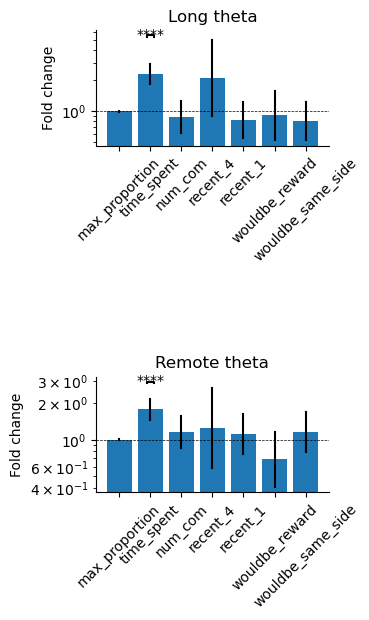

In [75]:
fig, axes = plt.subplots(2,1,figsize=(3, 6))
plt.subplots_adjust(hspace=2)

plot_params_one_axe(axes[0], result_long, "Long theta")

plot_params_one_axe(axes[1], result_remote, "Remote theta")

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/figure3_event_mixedGLM.pdf"
fig.savefig(file_path, format="pdf", dpi=300, bbox_inches="tight")

In [158]:
np.exp(2.06)

7.84596981031845

## Per rat data

In [97]:
features_animals[animal].keys()

dict_keys(['max_proportion', 'num_com', 'recent_4', 'recent_1', 'wouldbe_reward', 'wouldbe_same_side'])

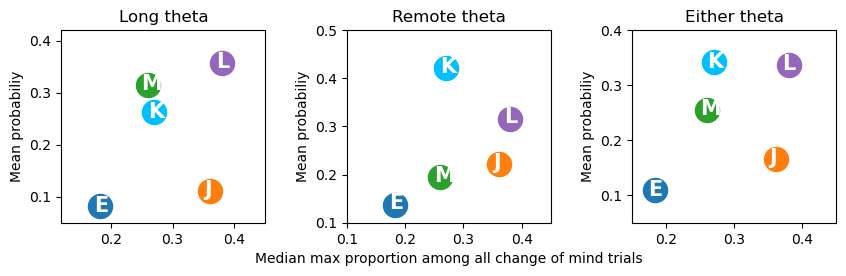

In [153]:
fig, axes = plt.subplots(1,3,figsize=(10, 2.5))
plt.subplots_adjust(wspace=0.4)

for animal in ["molly","eliot","julio","klein","lewis"]:
    x = np.median(features_animals[animal]['max_proportion'])
    y1 = np.mean(responses_animals[animal]['long_theta'])
    y2 = np.mean(responses_animals[animal]['remote_theta'])
    axes[0].scatter(x, y1, color = color_by_rat[animal], s = 300)
    axes[0].text(x-0.01, y1-0.01, animal[0].upper(), color = 'white', fontsize = 15,fontweight='bold')
    axes[0].set_xlim([0.12, 0.45])
    axes[0].set_ylim([0.05, 0.42])
    axes[0].set_title("Long theta")
    
    
    axes[1].scatter(x, y2, color = color_by_rat[animal], s = 300)
    axes[1].text(x-0.01, y2-0.01, animal[0].upper(), color = 'white', fontsize = 15,fontweight='bold')
    axes[1].set_xlim([0.1, 0.45])
    axes[1].set_ylim([0.1, 0.5])
    axes[1].set_title("Remote theta")

    y3 = np.mean(responses_animals[animal]['long_theta'] + responses_animals[animal]['remote_theta'])
    axes[2].scatter(x, y3, color = color_by_rat[animal], s = 300)
    axes[2].text(x-0.01, y3-0.01, animal[0].upper(), color = 'white', fontsize = 15,fontweight='bold')
    axes[2].set_xlim([0.15, 0.45])
    axes[2].set_ylim([0.05, 0.4])
    axes[2].set_title("Either theta")

    axes[0].set_ylabel("Mean probabiliy")
    axes[1].set_ylabel("Mean probabiliy")
    axes[2].set_ylabel("Mean probabiliy")
    axes[1].set_xlabel("Median max proportion among all change of mind trials")

    file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/MaxPropAverageAcrossRats.pdf"
    fig.savefig(file_path, format="pdf", dpi=300, bbox_inches="tight")

0.3577981651376147

## End here

In [7]:
nwb_copy_file_name = "lewis20240109_.nwb"
session_name = "02_Seq2Session1"
local_parameter = f"dur_{minimum_duration_long}_sd_{sd}_hpd{hpd}"

In [11]:
key = {
                    "nwb_file_name":nwb_copy_file_name,
                    "epoch":str(session_name[:2]),
                    "proportion": proportion,
                    "parameter":decode_name_long,
                    "local_parameter":local_parameter}
    
query = ChangeofMindTheta() & key

In [24]:
pandas = query.fetch1("pandas")
log_df = pd.DataFrame(pandas)
log_df =log_df[log_df.change_of_mind]

In [25]:
log_df

,timestamp_H,Home,timestamp_O,OuterWellIndex,rewardNum,change_of_mind,long_theta,theta_dev,short_theta_dev,long_theta_intervals,...,proportion_arm3,proportion_arm4,CoMNum_by_time,CoMNum_by_arm,CoM_arm,current,future_H,future_O,past,past_reward
18,1.704828e+09,1.0,1.704828e+09,2.0,2.0,True,False,[],"[-19.691492901567898, -14.64919055914504, 22.1...",[],...,0.000000,0.000000,3,1,"[[1, 2]]",2.0,2.0,1.0,4.0,1.0
24,1.704828e+09,1.0,1.704828e+09,4.0,2.0,True,False,[],"[-8.76416654797606, 8.584487328309848]",[],...,0.000000,0.000000,2,1,"[[1, 4, -9223372036854775808]]",4.0,4.0,3.0,2.0,2.0
46,1.704829e+09,1.0,1.704829e+09,2.0,2.0,True,False,[],[22.49622673221836],[],...,0.000000,0.000000,1,1,"[[1, 2, -9223372036854775808]]",2.0,2.0,3.0,4.0,1.0
55,1.704829e+09,1.0,1.704829e+09,2.0,2.0,True,True,[29.245738817540143],"[-17.24953519479783, 26.766427608812364]","[(1704829112.970363, 1704829113.0143628)]",...,0.000000,0.217687,3,3,"[[2, 1, 4, -9223372036854775808]]",2.0,2.0,4.0,3.0,1.0
63,1.704829e+09,1.0,1.704829e+09,1.0,2.0,True,True,"[45.054389827408556, 63.96769592248563]",[],"[(1704829384.7903116, 1704829384.8843117), (17...",...,0.000000,0.000000,1,1,"[[2, 1, -9223372036854775808]]",1.0,1.0,2.0,3.0,3.0
64,1.704829e+09,1.0,1.704829e+09,2.0,2.0,True,True,"[34.91710272926309, 29.665691152425097]",[],"[(1704829416.2063057, 1704829416.2943056), (17...",...,0.000000,0.503644,1,1,"[[4, 2, -9223372036854775808]]",2.0,2.0,1.0,1.0,1.0
65,1.704829e+09,1.0,1.704829e+09,1.0,1.0,True,False,[],[22.10271971717009],[],...,0.256088,0.000000,1,1,"[[3, 1, -9223372036854775808]]",1.0,1.0,4.0,2.0,2.0
68,1.704830e+09,1.0,1.704830e+09,2.0,1.0,True,False,[],"[9.107564174408992, 15.626559663955959]",[],...,0.000000,0.000000,2,1,"[[2, 1, -9223372036854775808]]",2.0,2.0,1.0,3.0,3.0
75,1.704830e+09,1.0,1.704830e+09,2.0,2.0,True,False,[],[-17.089127035266188],[],...,0.326543,0.000000,1,1,"[[3, 2, -9223372036854775808]]",2.0,2.0,4.0,1.0,1.0
81,1.704830e+09,1.0,1.704830e+09,3.0,2.0,True,True,[26.138227933762323],[],"[(1704829944.0042062, 1704829944.036206)]",...,0.000000,0.000000,1,1,"[[1, 3, -9223372036854775808]]",3.0,3.0,NaN,4.0,4.0


In [30]:
log_df.loc[63]

timestamp_H                                              1704829372.799406
Home                                                                   1.0
timestamp_O                                              1704829390.971463
OuterWellIndex                                                         1.0
rewardNum                                                              2.0
change_of_mind                                                        True
long_theta                                                            True
theta_dev                          [45.054389827408556, 63.96769592248563]
short_theta_dev                                                         []
long_theta_intervals     [(1704829384.7903116, 1704829384.8843117), (17...
short_theta_intervals                                                   []
change_of_mind_num                                                  [0, 0]
CoMMaxProportion                                                   0.50495
initial_choice           